In [1]:
import os
import sys
#sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))

import json
import numpy as np
import torch
import torch.nn as nn
import xarray as xr
import typing
import dataclasses
from collections import defaultdict
import inspect
from pprint import pprint
import copy

import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

In [2]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals
import diffusionsim.climsim_utils as cut

In [3]:
# exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

grad enabled:  False


'cuda'

In [ ]:
runs = {
    'diff' : evals.Run("LossWeightTesting",  "DiffusionTest"),
    'dist' : evals.Run("LossWeightTesting",  "DistSearch1"),
    'mse' : evals.Run("LossWeightTesting",  "JustMSE", cid=''),
    'oldjoint' : evals.Run("DiffLossTesting",  "trial4"),
    'joint' : evals.Run("LossWeightTesting",  "JointTest2"),
    "gradnorm" : evals.Run("MultiTask", "lr-sweep2", cid='')
} 

In [70]:
evals.Run("LossWeightTesting",  "JustMSE", cid='')

In [65]:
pkeys = "num_epochs phases distributed_training batch_logging_interval batch_checkpoint_interval log_gradients".split()
delete = True
for key in pkeys:
    for run_id in run.run_ids:
        tconfig = run.logs[run_id]['training_config']
        if key in tconfig:
            print(key, tconfig[key])
            if delete and key in inspect.signature(tru.DataConfig).parameters:
                run.logs['data_config'][key] = copy.deepcopy(tconfig[key])
                del tconfig[key]
        else:
            print(key, "not found")
            break

num_epochs not found
phases not found
distributed_training not found
batch_logging_interval not found
batch_checkpoint_interval not found
log_gradients not found


In [67]:
run.write_log()

In [66]:
rids = run.run_ids
for r in rids:
    tcon = run.logs[r]['training_config']
    tcon['diffusion_loss_decoding_stride'] = tcon['diffusion_loss_decoding_interval']
    run.logs['data_config']['checkpoint_best_epoch'] = tcon['save_best_epoch']
    del tcon['diffusion_loss_decoding_interval']
    del tcon['save_best_epoch']

In [40]:
for field in f:
    if field not in run.logs[run.run_ids[2]]['training_config']:
        print(field, "not found")

learning_rate_params not found
loss_weight_params not found
diffusion_strategy not found
diffusion_image_loss not found


In [39]:
run.write_log()

In [37]:

run.logs['data_config']

{'dataset_type': 'climsim',
 'climsim_type': 'low-res-expanded',
 'source': 'local-vzarr',
 'data_dir': '/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
 'train_test_split': [0.15, 0.05],
 'dataloader_params': {'batch_size': 98304,
  'shuffle': True,
  'num_workers': 0,
  'prefetch_factor': None,
  'persistent_workers': False,
  'multiprocessing_context': None,
  'pin_memory': True},
 'data_vars': 'v1',
 'use_tendencies': False,
 'norm_info': 'image',
 'chunksize': {},
 'log_batching': True,
 'shuffle_indices': True,
 'num_epochs': 10,
 'phases': ['train', 'eval'],
 'distributed_training': False,
 'batch_logging_interval': 16,
 'batch_checkpoint_interval': 50,
 'log_gradients': True}

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors

## Loss Curves

Four Workflows: 
1. Just Mse
2. MSE + Diffusion Prior Loss
3. MSE + Distribution Loss with KSD Gradient, uniform sample of 4 target variables
4. MSE + Distloss + Diffloss

In [8]:
run = runs['gradnorm']

In [9]:
for r in runs['dist'].run_ids: 
    losses = np.array(runs['dist'].get("losses", r)['train']['distribution'][-14:])
    print(r, losses[losses < 2].mean(), losses.mean())

DistSearch1-a 0.5547230146664395 1.4614280385719898
DistSearch1-b 0.6728279457181892 1.8270335444320234
DistSearch1-c 0.36808042590403556 0.49955120761919813
DistSearch1-d 0.781596840556027 1.6678787810009363
DistSearch1-e 0.5430700366619813 2.19582430947939
DistSearch1-f 0.42479703914114525 1.7526548058689821


In [17]:
for r in runs['gradnorm'].run_ids: 
    losses = np.array(runs['gradnorm'].get("losses", r)['train']['distribution'][-14:])
    print(r, losses[losses < 2].mean(), losses.mean())

lr-sweep2-a 0.14493760187574348 0.14493760187574348
lr-sweep2-b 0.08410215947293923 0.08410215947293923
lr-sweep2-c 0.07446579487394041 0.28733782602499575
lr-sweep2-d 0.08266301399110705 0.08266301399110705
lr-sweep2-e 0.09311749006423797 0.7246605335562525


In [18]:
for r in runs['joint'].run_ids: 
    losses = np.array(runs['joint'].get("losses", r)['train']['distribution'][-14:])
    print(r, losses[losses < 2].mean(), losses.mean())

JointTest21-mse 0.29460112322718907 0.9057597934772612
JointTest21-diff 0.5719734878881066 9.680603622753392
JointTest21-dist 0.527575531674293 0.7904988041639379
JointTest21-joint 0.5845451335532413 5.111792927280554


In [37]:
evals.plot_loss(runs["diff"], "mse", phase="train", title="", save_html=False)

In [ ]:
evals.plot_loss(runs["dist"], "distribution", phase="train", title="", save_html=False)

In [13]:
evals.plot_loss(runs["gradnorm"], "distribution", phase="train", title="", save_html=False)

In [12]:
evals.plot_gradients(runs['dist'], "distribution", "4.weight", log=False)

In [16]:
evals.plot_gradients(runs['gradnorm'], "distribution", "4.weight", log=False)

In [29]:
plot_gradients(runs['diff'], "mse", "4.weight", log=False)

In [ ]:
runs['dist'].logs[runs['dist'].run_ids[0]]['training_config']

{'exp_id': 'LossWeightTesting',
 'run_id': 'DistSearch1-a',
 'num_epochs': 10,
 'phases': ['train', 'eval'],
 'distributed_training': False,
 'optimizer': 'adam',
 'betas': [0.9, 0.999],
 'lr_scheduler': 'cosine',
 'learning_rate': 0.0001,
 'loss_weights': {'mse': 1.0, 'distribution': 0.1, 'diffusion': 0},
 'loss_schedule': {'mse': [0, 100],
  'distribution': [2, 100],
  'diffusion': [0, 100]},
 'clip_gradients': True,
 'max_T_sample': 100,
 'save_best_epoch': True,
 'batch_logging_interval': 16,
 'batch_checkpoint_interval': 50,
 'log_gradients': True,
 'push_to_hub': False,
 'diffusion_loss_noise_level': 20,
 'diffusion_loss_decoding_interval': 1,
 'distloss_type': 'ksd',
 'num_gaussians': [2, 2, 2],
 'num_distloss_samples': 8,
 'distloss_bs': 1152,
 'distloss_var_inds': [68, 73, 82],
 'distloss_var_sel': 'uniform'}

In [137]:
def validate_loss_total(run):
    for run_id in run.run_ids:
        lws, loss_sched, num_epochs = run.get("loss_weights", run_id), run.get("loss_schedule", run_id), run.get("num_epochs", run_id)
        total_losses = np.array(run.get("losses", run_id)['train']['total'])
        sum_total_others = np.zeros_like(total_losses)
        for loss, (start_epoch, end_epoch) in loss_sched.items():
            if loss not in run.get("losses", run_id)['train']:
                continue
            loss_array = np.array(run.get("losses", run_id)['train'][loss])
            start = int(min(1, start_epoch/num_epochs) * len(loss_array))
            end = int(min(1, end_epoch/num_epochs) * len(loss_array))
            if start < end:
                sum_total_others[start:end] += lws[loss] * loss_array[start:end]
        matching = np.allclose(total_losses, sum_total_others)
        print(run_id, matching)
        if not matching:
            print(f"{loss} : epoch {start_epoch}:{end_epoch} / {num_epochs} <==> index {start}:{end} / {len(loss_array)}")
            return total_losses, sum_total_others
    return None, None


In [141]:
total, sumt = validate_loss_total(runs['joint'])

JointTest21-mse True
JointTest21-diff True
JointTest21-dist True
JointTest21-joint True


In [105]:
run['diff'].get("loss_schedule")

[{'mse': [11, 11], 'distribution': [0, 100], 'diffusion': [0, 100]},
 {'mse': [0, 5], 'distribution': [0, 100], 'diffusion': [0, 100]},
 {'mse': [0, 5], 'distribution': [0, 100], 'diffusion': [0, 100]},
 {'mse': [0, 12], 'distribution': [0, 100], 'diffusion': [0, 100]},
 {'mse': [0, 12], 'distribution': [0, 100], 'diffusion': [0, 100]}]

In [106]:
evals.plot_loss(runs['diff'], 'mse', phase='train')

In [104]:
evals.plot_loss(runs['dist'], 'mse', phase='train')

In [115]:
plot_gradients(runs['dist'], 'distribution', '4.weight', log=False)

In [111]:
runs['dist'].get("loss_weights", 0)

{'mse': 1.0, 'distribution': 0.1, 'diffusion': 0}

In [1]:
evals.plot_loss(run['dist'], 'mse', phase='train')

NameError: name 'evals' is not defined

In [38]:
evals.plot_loss(runs["diff"], "diffusion", phase="train", title="", save_html=False)

## Loading data and predictions

In [19]:
run = runs['diff']
loss_fn = torch.nn.MSELoss()
trainer = run.reconstruct_trainer(apply_checkpoints=True, apply_indices=True, increment_run_id=False)

Invalid indices


ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [20]:
pprint(run.dconfig)
dl, edl = trainer.dataloaders['train'], trainer.dataloaders['eval']
len(dl), len(edl)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.15, 0.05],
           dataloader_params=DataLoaderParams(batch_size=98304,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=True)


(123, 41)

In [21]:
dl.dataset.X.sample.shape[0] / 384 / run.dconfig.train_test_split[0]

210233.33333333334

In [22]:
bs, bli = run.get("dataloader_params")['batch_size'], run.get_tconfig(0).batch_logging_interval
bs, bli, bs/384

(98304, 16, 256.0)

In [23]:
ds = edl.dataset
loaded = False
print(ds.X.nbytes / 1e9)
if(ds.X.nbytes / 1e9 < 1):
    loaded = True
    from dask.diagnostics import ProgressBar
    with ProgressBar():
        ds.X.load()
        ds.Y.load()

    X, Y = torch.tensor(edl.dataset.X.data), torch.tensor(edl.dataset.Y.data)
    print(X.shape, Y.shape)

4.003934208


In [41]:
trainers.diffusion_loss(trainer, predictions['true'], predictions.run_ids[0])

AttributeError: 'dict' object has no attribute 'run_ids'

In [24]:
mli, mlo = ds.mli, ds.mlo
len(ds), ds.X.shape, ds.xgen.input_dims

(41, (4036224, 124), {'sample': 98304, 'mli': 124})

In [27]:
print(ds.X.shape[0] // bs, )
print(bs / 384)

desired_sample_size = 2 * 384 * 256

import xbatcher
ds.xgen = xbatcher.BatchGenerator(ds.X, input_dims=dict(sample=desired_sample_size, mli=ds.dutils.input_feature_len), preload_batch=False,)
ds.ygen = xbatcher.BatchGenerator(ds.Y, input_dims=dict(sample=desired_sample_size, mlo=ds.dutils.target_feature_len), preload_batch=False,)
BATCH = np.random.randint(0, len(ds.xgen))
print(BATCH)

41
256.0
13


In [26]:
x, y = ds[0]
x_data_backup, y_data_backup = x, y

{"event": "get-item start", "time": 1755093099.4287827, "pid": 2580880, "batch_idx": 0}
{"event": "get-item end", "time": 1755093242.8502939, "pid": 2580880, "batch_idx": 0, "duration": 143.4214985370636}


In [28]:
for name, p in run.get_model(0).params.items():
    print(name, p.shape, p.mean())

0.weight torch.Size([256, 124]) tensor(0.0013, device='cuda:0')
0.bias torch.Size([256]) tensor(0.0016, device='cuda:0')
2.weight torch.Size([256, 256]) tensor(0.0024, device='cuda:0')
2.bias torch.Size([256]) tensor(0.0057, device='cuda:0')
4.weight torch.Size([256, 256]) tensor(0.0025, device='cuda:0')
4.bias torch.Size([256]) tensor(0.0012, device='cuda:0')
6.weight torch.Size([256, 256]) tensor(0.0011, device='cuda:0')
6.bias torch.Size([256]) tensor(0.0045, device='cuda:0')
8.weight torch.Size([128, 256]) tensor(-0.0012, device='cuda:0')
8.bias torch.Size([128]) tensor(0.0034, device='cuda:0')


In [29]:
predictions = {}
x = x.to(device)
with torch.no_grad():
    predictions['true'] = y.detach()
    print(y.isnan().sum().item(), "true", y.shape)
    for key in runs['diff'].models.keys():
        run.models[key].model.eval()
        pred = run.models[key].model(x)
        print(pred.isnan().sum().item(), key, pred.shape)
        predictions[key] = pred.detach().cpu()
    predictions['JustMSE-d'] = runs['mse'].get_model('JustMSE-d')(x).detach().cpu()

0 true torch.Size([196608, 128])
0 DiffusionTest1-a torch.Size([196608, 128])
0 DiffusionTest1-b torch.Size([196608, 128])
0 DiffusionTest1-c torch.Size([196608, 128])
0 DiffusionTest1-d torch.Size([196608, 128])
0 DiffusionTest1-e torch.Size([196608, 128])


In [43]:
real = predictions['true']

In [30]:
trainer.run_ids
mse_trainer = runs['mse'].reconstruct_trainer(True, True, False)

Invalid indices


In [31]:
mse_trainer.schedulers = {}
s = trainer.schedulers[trainer.run_ids[0]]
for r in mse_trainer.run_ids:
    mse_trainer.schedulers[r] = s

mse_trainer.unet = trainer.unet

In [32]:
predictions.keys()

dict_keys(['true', 'DiffusionTest1-a', 'DiffusionTest1-b', 'DiffusionTest1-c', 'DiffusionTest1-d', 'DiffusionTest1-e', 'JustMSE-d'])

In [86]:
mse_losses = {}
distlosses = {}
difflosses = {}
var_inds = []

for key, pred in predictions.items():
    if key == "true":
        continue
    trainer_to_use = mse_trainer if "mse" in key.lower() else trainer
    mse_losses[key] = loss_fn(pred, y)
    distlosses[key], VAR_IND = trainers.distribution_loss(trainer_to_use, pred.to(device), y.to(device), step=0, run_id=key)
    var_inds.append(VAR_IND)
    difflosses[key] = trainers.diffusion_loss(trainer_to_use, pred.to(device), run_id=key)

tensor(0.0310, device='cuda:0')

In [47]:
trainer.run_ids[0]

'DiffusionTest1-a'

In [ ]:
real.shape

{'DiffusionTest1-a': tensor(8.1144),
 'DiffusionTest1-b': tensor(1.1177),
 'DiffusionTest1-c': tensor(1.1446),
 'DiffusionTest1-d': tensor(0.2841),
 'DiffusionTest1-e': tensor(0.6583),
 'JustMSE-d': tensor(0.0990)}

In [87]:
import pandas as pd
data = {
    key: {
        "mse": mse_losses[key].item(),
        "diff": difflosses[key].item(),
        "dist": distlosses[key].item(),
    }
    for key in mse_losses.keys()
}

df = pd.DataFrame.from_dict(data, orient="index")
df['VAR_IND'] = var_inds

$L_{diff} = MSE(\hat{y}, D(E(\hat{y})))$


Do it differently: 

- Implement latent space (train a VAE or something) --> $D_{latent}$
- $L = D_{latent}(y, D(E(y)))$
- Project y_hat into the latent space of the diffusion model (capture some sort of distributional difference)
- Overfitting diffusion loss (less than "real" image of 0.031). Could that mean training set is biased and we are converging to center? 

Look into Mahanobis Distance

In [50]:
trainers.diffusion_loss(trainer, real.to(device), run_id='DiffusionTest1-a')

tensor(0.0310, device='cuda:0')

In [88]:
df

,mse,diff,dist,VAR_IND
DiffusionTest1-a,8.114375,0.045908,2.895814,73
DiffusionTest1-b,1.117691,0.027996,0.730314,73
DiffusionTest1-c,1.144560,0.028597,0.044316,82
DiffusionTest1-d,0.284059,0.029086,21.754472,73
DiffusionTest1-e,0.658267,0.027916,106.920614,68
JustMSE-d,0.099031,0.031701,10.727541,68


### Old test: Just Distloss

In [4]:
#exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DistLossTesting"
run_id = "trial1"
base_dir = os.path.join(exp_dir, exp_id)
log_dicts = {}
mconfigs = []
distloss_models = {}
base_dir

'/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments/DistLossTesting'

In [ ]:
lettering = 'abcdefghijklmnopqrstuvwxyz'
for i in range(4):
    fpath = os.path.join(base_dir, f"trial1{lettering[i]}.json")
    print(fpath)
    with open(fpath, 'r') as f:
        log_dict = json.load(f)
    model_path = os.path.join(base_dir, "checkpoints", )
    mconfig = tru.ModelConfig(**log_dict['model_config'])
    mconfigs.append(mconfig)
    distloss_models[targeted_vars[i]] = tru.load_model_from_ckpt(f"checkpoints/{run_id}{lettering[i]}-ckpt.pt", mconfig, exp_id, exp_dir, baseline=True)
    log_dicts[targeted_vars[i]] = log_dict


In [ ]:
mse_base_dir = os.path.join(exp_dir, "JointTraining")
with open(mse_base_dir + "/trial0.json", 'r') as f:
    mse_log_dict = json.load(f)
mse_model = tru.load_model_from_ckpt("checkpoints/trial0_just_mse.pt", mse_log_dict['model_config'], "JointTraining", exp_dir, baseline=True).to(device)


/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

In [10]:
dconfig = tru.my_dconfig(data_vars='v1', in_notebook=True, dataset_type='climsim', batch_size=64)
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.01, 0.002]
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)

In [11]:
dl, edl = dataloaders
batch = dl.dataset[8]

{"event": "get-batch start", "time": 1746556633.1034007, "pid": 201, "batch_idx": 8}
{"event": "get-batch end", "time": 1746556639.235854, "pid": 201, "batch_idx": 8, "duration": 6.1324462890625}


In [12]:
import dask
from dask.diagnostics import ProgressBar
with ProgressBar():
    edl.dataset.X.load()
    edl.dataset.Y.load()

[########################################] | 100% Completed | 2.53 sms
[########################################] | 100% Completed | 2.76 sms


## Distribution Assessment of Predictions 


Compare the distribution and images predicted by each model to the actual images and actual histograms of select variables

In [127]:
from ipywidgets import interact, widgets
predictions.keys()

dict_keys(['true', 'DiffusionTest1-a', 'DiffusionTest1-b', 'DiffusionTest1-c', 'DiffusionTest1-d', 'DiffusionTest1-e'])

In [128]:
denormalized_predictions = {}
for key, pred in predictions.items():
    print(key, pred.shape)
    xd, predd = ds.denormalize(x, pred)
    denormalized_predictions[key] = predd.numpy()

true (1572864, 128)
DiffusionTest1-a torch.Size([1572864, 128])
DiffusionTest1-b torch.Size([1572864, 128])
DiffusionTest1-c torch.Size([1572864, 128])
DiffusionTest1-d torch.Size([1572864, 128])
DiffusionTest1-e torch.Size([1572864, 128])


In [129]:
denormalized_predictions['true'][:,59]

array([294.15118, 290.97034, 296.85815, ..., 271.23923, 267.4616 ,
       277.2591 ], dtype=float32)

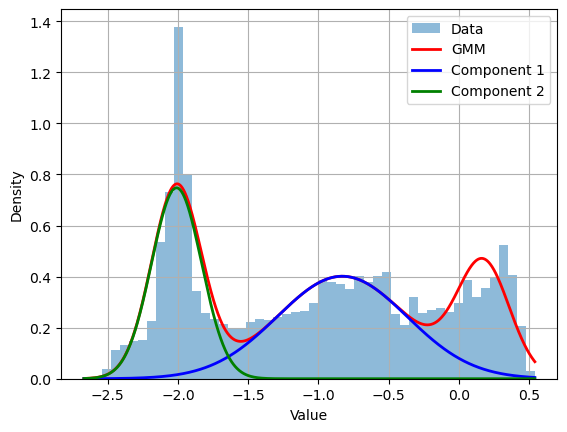

In [130]:
VAR_IND = 68
num_gaussians = 3
y_sel = y[:, VAR_IND]
gmm = GaussianMixture(n_components=num_gaussians)
gmm.fit(y_sel[:, None])
densities = evals.plot_gmm_distribution(y_sel, gmm, components=True)

In [131]:
if (torch.is_tensor(y)):
    y = y.detach().cpu().numpy()

def discrepancy_viewer(predictions, cmap='viridis'):
    # Define interactive plot function
    viewable_keys = list(predictions.keys())
    var_inds = [68, 60, 73, 82]
    num_gaussians = [3, 2, 3, 2]

    def plot_image(var_index, model_index):
        VAR_IND = var_inds[var_index]
        mtype = viewable_keys[model_index]
        y_sel = predictions['true'][:, VAR_IND]
        gmm = GaussianMixture(n_components=num_gaussians[var_index])
        gmm.fit(y_sel[:, None])
        pred = predictions[mtype][:, VAR_IND]

        x = torch.linspace(pred.min(), pred.max(), 1000)
        densities = torch.exp(torch.tensor(gmm.score_samples(x.reshape(-1,1))))
        plt.plot(x, densities, label='gmm density learned from y')
        plt.hist(pred, density=True, label=f'{mtype} predictions', bins=50, alpha=0.75)
        #plt.hist(y_sel, density=True, label='histogram of y', bins=50, alpha=0.5)
        plt.title(f"Predictions of {mlo[VAR_IND].item()} ({VAR_IND}) from model {mtype}")
        plt.legend()

    # Create interactive widgets
    variable_slider = widgets.IntSlider(value=0, min=0, max=len(var_inds)-1, step=1, description='Variable:')
    model_slider = widgets.IntSlider(value=0, min=0, max=len(viewable_keys)-1, step=1, description='Model:')
    interact(plot_image, var_index=variable_slider, model_index=model_slider)
    

In [136]:
run.get_tconfig(0)

TrainingConfig(exp_id='LossWeightTesting', run_id='DiffusionTest1-a', num_epochs=10, phases=['train', 'eval'], distributed_training=False, optimizer='adam', learning_rate_params={'learning_rate': 0.0002, 'lr_scheduler': 'cosine', 'patience': 5, 'betas': [0.9, 0.999], 'lr_warmup_steps': 20, 'step_size': 100, 'gamma': 0.9, 'min_lr': 1e-06}, loss_weight_params={'strategy': 'gradnorm', 'lr': 0.025, 'alpha': 0.5, 'gradnorm_layer': -2, 'T': 3.0, 'update_interval': 5, 'loss_weights': {'mse': 1.0, 'distribution': 0.0, 'diffusion': 50.0}, 'loss_schedule': {'mse': [11, 11], 'distribution': [0, 100], 'diffusion': [0, 100]}}, clip_gradients=True, max_T_sample=100, save_best_epoch=True, batch_logging_interval=16, batch_checkpoint_interval=50, log_gradients=True, push_to_hub=False, diffusion_loss_noise_level=20, diffusion_loss_decoding_interval=1, distloss_type='ksd', num_gaussians=[2, 2, 2], num_distloss_samples=8, distloss_bs=1152, distloss_var_inds=[68, 73, 82], distloss_var_sel='uniform')

In [132]:
discrepancy_viewer(predictions)

interactive(children=(IntSlider(value=0, description='Variable:', max=3), IntSlider(value=0, description='Mode…

## Regression to the Mean? 

In [51]:
ddpm = tru.load_diffusion_model()
mconfig = run.get_mconfig(0)
mconfig.scheduler_type  = 'ddim'
scheduler = tru.load_scheduler(mconfig)
scheduler.config.timestep_spacing = "linspace"  

In [52]:
pipeline = evals.SampleImages(ddpm, scheduler, batch_size=10)

In [53]:
predictions.keys()

dict_keys(['true', 'DiffusionTest1-a', 'DiffusionTest1-b', 'DiffusionTest1-c', 'DiffusionTest1-d', 'DiffusionTest1-e', 'JustMSE-d'])

In [54]:
x0 = cut.imagify(predictions['true'].to(device), ds.dutils, 'y', 2)
x0.shape

torch.Size([512, 128, 16, 24])

In [55]:
dist = torch.nn.MSELoss()
def mean_dist(xt, x0):
    #mu = torch.tensor(Y_mean_img, dtype=xt.dtype, device=xt.device)
    return(dist(xt, torch.zeros_like(xt)).item())

def x0_deviation_dist(xt, x0):
    return(dist(xt, x0).item()) 

res = pipeline.encode_decode(x0, 25, stride=1, timestep_funcs={"mean_dist": mean_dist, "x0_deviation_dist": x0_deviation_dist})


In [56]:
def encode_decode_dists(x0, T, pipeline_generator=pipeline):
    pipeline_generator.scheduler.set_timesteps(pipeline_generator.scheduler.config.num_train_timesteps)
    distances = []
    d2 = []
    dist = torch.nn.MSELoss()
    for t in range(T):
        xt, eps = pipeline_generator.encode(x0, t)
        distances.append(dist(x0, xt).item())
        d2.append(dist(xt, torch.zeros_like(xt)).item())

    for t in range(T, 1, -1): # pipe.scheduler.timesteps[-T//stride-1:]
        xt, _ = pipeline_generator._denoise(xt, t)
        distances.append(dist(x0, xt).item())
        d2.append(dist(xt, torch.zeros_like(xt)).item())
    return(np.array(distances), np.array(d2))

In [57]:
d = {}
for key, pred in predictions.items():
    x0 = cut.imagify(pred.to(device), ds.dutils, 'y', 2)
    x0 = x0[torch.randint(low=0, high=x0.shape[0], size=(64,))]
    print(key, x0.shape)
    d[key] = encode_decode_dists(x0, 25)

true torch.Size([64, 128, 16, 24])
DiffusionTest1-a torch.Size([64, 128, 16, 24])
DiffusionTest1-b torch.Size([64, 128, 16, 24])
DiffusionTest1-c torch.Size([64, 128, 16, 24])
DiffusionTest1-d torch.Size([64, 128, 16, 24])
DiffusionTest1-e torch.Size([64, 128, 16, 24])
JustMSE-d torch.Size([64, 128, 16, 24])


In [58]:
# Prepare data_dict in the format your interactive_plot expects
data_dict = {}
tx = list(range(len(res["T"])))
# Other runs from dictionary d
for key, values in d.items():
    data_dict[key] = [go.Scatter(x=tx, y=values[1], mode="lines", name=key)]

# X-axis tick labels: timesteps instead of index
tick_positions = list(range(0, len(res["T"]), max(len(res["T"])//10, 1)))
tick_labels = [res["T"][i] for i in tick_positions]

# Pass axis titles and tick formatting into plot_data
plot_data = {
    "title": "Mean Distance vs Timestep",
    "xaxis_title": "Timestep",
    "yaxis_title": "Mean Distance"
}

evals.interactive_plot(data_dict, plot_data)

In [259]:
# Prepare data_dict in the format your interactive_plot expects
data_dict = {}

# "true" trace
data_dict["true"] = [go.Scatter(x=x, y=res["x0_deviation_dist"], mode="lines", name="true" )]

# Other runs from dictionary d
for key, values in d.items():
    data_dict[key] = [go.Scatter(x=x, y=values[0], mode="lines", name=key)]

# X-axis tick labels: timesteps instead of index
tick_positions = list(range(0, len(res["T"]), max(len(res["T"])//10, 1)))
tick_labels = [res["T"][i] for i in tick_positions]

# Pass axis titles and tick formatting into plot_data
plot_data = {
    "title": "Regression to Mean Effect",
    "xaxis_title": "Timestep",
    "yaxis_title": "Mean Distance"
}

interactive_plot(data_dict, plot_data, save_html=True)

plotly.html


In [244]:
for key, pred in predictions.items():
    print(key, pred.mean().item())

true -0.12187959998846054
DiffusionTest1-a -0.5928885340690613
DiffusionTest1-b -0.37461817264556885
DiffusionTest1-c -0.2623210549354553
DiffusionTest1-d -0.09621924161911011
DiffusionTest1-e -0.008897588588297367


In [248]:
loss_fn = torch.nn.MSELoss()
for key, pred in predictions.items():
    print(key, loss_fn(pred, predictions['true']))

true tensor(0.)
DiffusionTest1-a tensor(9.1916)
DiffusionTest1-b tensor(1.1542)
DiffusionTest1-c tensor(1.1537)
DiffusionTest1-d tensor(0.2710)
DiffusionTest1-e tensor(0.5522)


In [151]:
predictions['trial4-diff'].mean()

tensor(-0.0808)

In [153]:
trainer.loss_fn(predictions['trial4-mse'], torch.zeros_like(predictions['trial4-mse']))

tensor(4.1121)

In [ ]:
trainer.loss_fn(predictions['trial4-diff'], torch.zeros_like(predictions['trial4-diff']))

tensor(4.0423)

In [170]:
import numpy as np
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca_data_vs_preds(y_true, y_pred1, y_pred2, n_components=2, title="PCA comparison"):
    """
    y_true: numpy or torch array of true targets, shape (N, D)
    y_pred1: predictions from model 1, shape (N, D)
    y_pred2: predictions from model 2, shape (N, D)
    n_components: PCA components (2 for 2D scatter plot)
    """
    
    # Stack all for fitting PCA
    all_data = np.concatenate([y_true, y_pred1, y_pred2], axis=0)
    
    # Fit PCA
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(all_data)
    
    # Split back
    n = len(y_true)
    pca_true = pca_data[:n]
    pca_pred1 = pca_data[n:n+len(y_pred1)]
    pca_pred2 = pca_data[n+len(y_pred1):]

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(pca_true[:, 0], pca_true[:, 1], label="True y", alpha=0.5, marker='o')
    plt.scatter(pca_pred1[:, 0], pca_pred1[:, 1], label="Predictions Model 1", alpha=0.5, marker='x')
    plt.scatter(pca_pred2[:, 0], pca_pred2[:, 1], label="Predictions Model 2", alpha=0.5, marker='^')
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
# plot_pca_data_vs_preds(y_true, y_pred1, y_pred2)


/srv/conda/envs/notebook/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


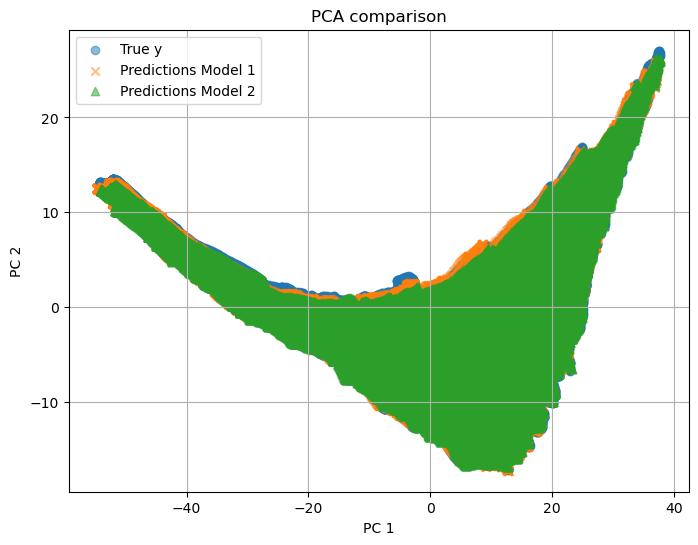

In [172]:
true, p1, p2 = predictions['true'], predictions['trial4-mse'], predictions['trial4-diff']

plot_pca_data_vs_preds(true.numpy(), p1.numpy(), p2.numpy())

## Image Comparison

In [63]:
pred_images = {}
for key, pred in predictions.items():
    pred_images[key] = trainer._make_image(torch.tensor(pred)).numpy()
    print(pred_images[key].shape)

keys = list(pred_images.keys())
keys

(4096, 128, 16, 24)


/tmp/ipykernel_1469945/1997126170.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred_images[key] = trainer._make_image(torch.tensor(pred)).numpy()


(4096, 128, 16, 24)
(4096, 128, 16, 24)
(4096, 128, 16, 24)
(4096, 128, 16, 24)


['true', 'trial4-mse', 'trial4-diff', 'trial4-dist', 'trial4-joint']

In [64]:
denormalized_pred_images = {}
for key, pred in denormalized_predictions.items():
    denormalized_pred_images[key] = trainer._make_image(torch.tensor(pred)).numpy()
    print(pred_images[key].shape)

(4096, 128, 16, 24)
(4096, 128, 16, 24)
(4096, 128, 16, 24)
(4096, 128, 16, 24)
(4096, 128, 16, 24)


In [65]:
def image_viewer(pred_images=pred_images, cmap='plasma'):
    # Define interactive plot function
    viewable_keys = list(pred_images.keys())
    batch_size = pred_images[viewable_keys[-1]].shape[0]
    y_img = trainer._make_image(torch.tensor(y)).numpy()
    def plot_image(batch_index, var_index, model_index):
        var = mlo[var_index].item()
        mtype = viewable_keys[model_index]
        vmap = pred_images[mtype][batch_index, var_index, :, :]
        plt.imshow(vmap, cmap=cmap)
        plt.colorbar()
        plt.title(f"Predictions of {var} from {mtype} model")
        plt.ylabel("Latitude")
        plt.xlabel("Longitude")
        plt.show()

    # Create interactive widgets
    batch_slider = widgets.IntSlider(value=0, min=0, max=batch_size-1, step=1, description='Item:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=len(mlo)-1, step=1, description='Variable:')
    model_slider = widgets.IntSlider(value=0, min=0, max=len(viewable_keys)-1, step=1, description='Model:')
    interact(plot_image, batch_index=batch_slider, var_index=variable_slider, model_index=model_slider)

In [ ]:
image_viewer(denormalized_pred_images)

interactive(children=(IntSlider(value=0, description='Item:', max=4095), IntSlider(value=0, description='Varia…

In [69]:
trainer.training_configs.keys()

dict_keys(['trial5-mse', 'trial5-diff', 'trial5-dist', 'trial5-joint'])

In [68]:
truth = torch.tensor(predictions['true'], device=device)

import time
metrics_dict = {}

target_variables_distloss = [68, 60, 73, 82]
num_gaussians = [3, 2, 3, 2]

metric_names = ['mse', 'distloss', 'diffloss']

with torch.no_grad():
    for key, pred in predictions.items():
        pred = torch.tensor(pred, device=device)
        if key == 'true':
            continue
        tconfig = run.get_tconfig(key)
        tconfig.distloss_var_inds = 68
        tconfig.num_gaussians = 3
        metrics = []
        metrics.append(torch.nn.MSELoss()(pred, truth).item())
        metrics.append(trainer.distribution_loss(pred, truth, tconfig, 0)[0].item())
        print("calculating diffloss")
        t = time.time()
        metrics.append(trainer.diffusion_loss(pred, key).item())
        print("done after", time.time() - t)
        metrics_dict[key] = metrics




/tmp/ipykernel_1469945/2767165186.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = torch.tensor(pred, device=device)


calculating diffloss


KeyError: 'trial4-mse'

In [121]:
"""
for key, var in trainer.training_configs.items():
    trainer.training_configs[key.replace('3', '4')] = var
"""

trainer.training_configs.keys()

dict_keys(['trial3-mse', 'trial3-diff', 'trial3-dist', 'trial3-joint'])

dict_keys(['trial3-mse', 'trial3-diff', 'trial3-dist', 'trial3-joint'])

In [134]:
metrics_dict, metric_names

({'trial3-mse': [0.0724414810538292, 1.0079319096195756, 0.030558183789253235],
  'trial3-diff': [0.08307360857725143,
   2.095526471205132,
   0.029028963297605515],
  'trial3-dist': [0.435153603553772, 1.247382049213664, 0.058778077363967896],
  'trial3-joint': [0.4449161887168884,
   3.8395761725522433,
   0.032129429280757904]},
 ['mse', 'distloss', 'diffloss'])

In [135]:
metrics_df = pd.DataFrame(metrics_dict).T
metrics_df.columns = metric_names
metrics_df

,mse,distloss,diffloss
trial3-mse,0.072441,1.007932,0.030558
trial3-diff,0.083074,2.095526,0.029029
trial3-dist,0.435154,1.247382,0.058778
trial3-joint,0.444916,3.839576,0.032129


## Gradient Analysis

In [84]:
log_dicts2['trial4-joint']['gradients'].keys()

dict_keys(['mse', 'distribution', 'diffusion'])

In [86]:
plot_gradients(log_dicts2, "distribution")

(130, 2) 130 13
(130, 2) 130 13
(130, 2) 130 13
(130, 2) 130 13


In [107]:
plot_gradients(log_dicts, "distribution", log=False)


(40, 2) 40 4
(40, 2) 40 4
(40, 2) 40 4
(40, 2) 40 4


(130, 2)
256.0 32 12.0 130 11
(130, 2)
256.0 32 12.0 130 11
(130, 2)
256.0 32 12.0 130 11
(130, 2)
256.0 32 12.0 130 11


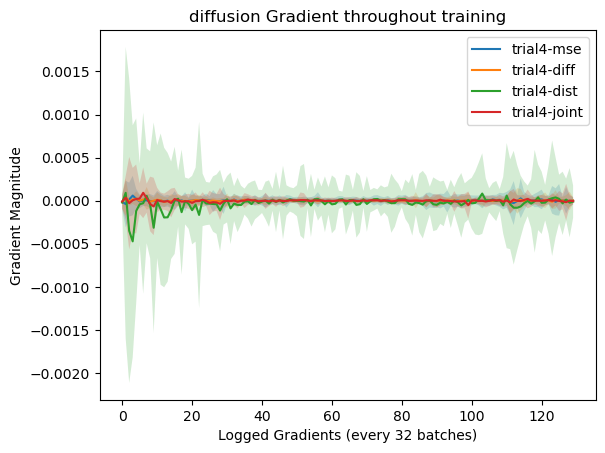

In [105]:
plot_gradients(log_dicts, "diffusion")

# Trying to use data utils
- replicate https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html
- https://github.com/leap-stc/ClimSim/blob/main/preprocessing/create_npy_data_splits.ipynb

Inspired by [Climsim guide](https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html)

In [41]:
from diffusionsim import climsim_utils as cut
from diffusionsim import mydatasets as data

In [42]:
dutils = cut.dutils_from_config(dconfig)
self = dutils


In [43]:
xdn, ydn = self.denormalize(x, y)


In [44]:
ydn.shape

(1572864, 128)

In [47]:
dp = self.compute_dp(xdn, undo_norm=False)
var_weights = self.get_var_weights(ydn, dp, "dict")

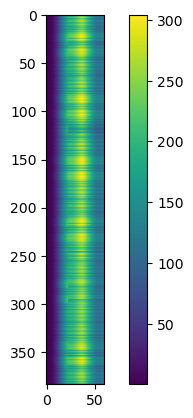

In [48]:
plt.imshow(var_weights['state_t'][0])
plt.colorbar()
plt.show()

In [49]:

y_weighted = dutils.output_weighting(x, y, undo_norm=True)
for k, v in y_weighted.items():
    print(k, v.shape, v.mean(), v.std())

state_t (4096, 384, 60) 34872.12878657008 20671.39844897868
state_q0001 (4096, 384, 60) 931.6704767134928 1473.1589728772906
cam_out_NETSW (4096, 384) 161.3381421006673 257.7409897039232
cam_out_FLWDS (4096, 384) 343.79467048105494 85.40527574619024
cam_out_PRECSC (4096, 384) 7.777216758719317 19.38786465102163
cam_out_PRECC (4096, 384) 71.50323779341868 204.20210859962629
cam_out_SOLS (4096, 384) 63.115758225887106 115.35318308730804
cam_out_SOLL (4096, 384) 68.91621076103563 121.51055696350313
cam_out_SOLSD (4096, 384) 34.1532332502918 46.489397072288156
cam_out_SOLLD (4096, 384) 18.218090123205904 29.812913967501345


In [64]:
dutils.metrics_names = ['MAE', 'RMSE', 'R2', 'bias']
#df_var, df_idx = dutils.create_metrics_df(x, y, predictions, apply_weighting=False)

metrics_var_train = {}
metrics_idx_train = {}

In [95]:
for model_name, preds in predictions.items():
    df_var = pd.DataFrame(columns = self.metrics_names, index = self.target_vars)
    df_var.index.name = 'variable'
    df_idx = pd.DataFrame(columns = self.metrics_names, index = range(self.target_feature_len))
    df_idx.index.name = 'output_idx'
    for metric_name in self.metrics_names:
        current_idx = 0
        metric_fn = self.metrics_dict[metric_name]
        for target_var in self.target_vars:
            start, stop = self.target_var_idx[target_var]
            if(target_var in self.level_variables):
                pred_var = preds[:, start:stop].reshape(-1, self.num_latlon, 60).numpy()
                y_var = y[:, start:stop].reshape(-1, self.num_latlon, 60).numpy()
            else:
                pred_var = preds[:, start:stop].reshape(-1, self.num_latlon).numpy()
                y_var = y[:, start:stop].reshape(-1, self.num_latlon).numpy()
            metric = metric_fn(pred_var, y_var)
            if(metric_name == 'R2'):
                metric = metric.clip(min = -1)
            df_var.loc[target_var, metric_name] = np.mean(metric)
            df_idx.loc[current_idx:current_idx + self.var_lens[target_var] - 1, metric_name] = np.atleast_1d(metric)
            current_idx += self.var_lens[target_var]
    m1, m2 = df_var.mean(), df_idx.mean()
    m1.name, m2.name = 'average', 'average'
    df_var, df_idx = pd.concat([df_var, m1.to_frame().T]), pd.concat([df_idx, m2.to_frame().T])
    metrics_var_train[model_name] = df_var
    metrics_idx_train[model_name] = df_idx

In [96]:
metrics_var_train.keys()

dict_keys(['true', 'trial4-mse', 'trial4-diff', 'trial4-dist', 'trial4-joint'])

In [156]:
metrics_var_train['trial4-mse']

,MAE,RMSE,R2,bias
state_t,0.113427,0.142499,0.83486,-0.005801
state_q0001,0.101297,0.126824,0.296811,-0.004198
cam_out_NETSW,0.15855,0.233297,0.551625,0.01363
cam_out_FLWDS,0.301277,0.369328,0.623823,-0.046278
cam_out_PRECSC,0.607036,0.834105,-1.0,0.013326
cam_out_PRECC,0.39444,0.665274,-1.0,0.01232
cam_out_SOLS,0.186257,0.303365,0.369409,0.024446
cam_out_SOLL,0.20651,0.336037,0.522673,0.012876
cam_out_SOLSD,0.213008,0.33175,0.873286,0.007086
cam_out_SOLLD,0.304261,0.499108,0.629055,0.013528


In [157]:
metrics_var_train['trial4-diff']

,MAE,RMSE,R2,bias
state_t,0.1266,0.159278,0.815888,-0.000538
state_q0001,0.102528,0.129257,0.290365,0.007742
cam_out_NETSW,0.162157,0.240705,0.681909,-0.008907
cam_out_FLWDS,0.317479,0.382655,0.612755,-0.057897
cam_out_PRECSC,0.629824,0.867322,-1.0,-0.015791
cam_out_PRECC,0.390567,0.664188,-1.0,-0.036729
cam_out_SOLS,0.200028,0.317377,0.151229,-0.002686
cam_out_SOLL,0.217687,0.346659,0.550617,0.002031
cam_out_SOLSD,0.22471,0.350764,0.861039,-0.003528
cam_out_SOLLD,0.317436,0.523238,0.597567,-0.01323


In [50]:
dutils.metrics_names = ['MAE', 'RMSE', 'R2', 'bias']
metrics_var_train, metrics_idx_train = dutils.create_metrics_df(x, y, predictions, apply_weighting=True)

/tmp/ipykernel_2342621/3068988559.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  predictions[key] = torch.tensor(var)


Applying variable reweighting to y even though use_tendencies is False! Proceed with caution.


Applying variable reweighting to prediction even though use_tendencies is False! Proceed with caution.
Applying variable reweighting to prediction even though use_tendencies is False! Proceed with caution.
Applying variable reweighting to prediction even though use_tendencies is False! Proceed with caution.
Applying variable reweighting to prediction even though use_tendencies is False! Proceed with caution.
Applying variable reweighting to prediction even though use_tendencies is False! Proceed with caution.


In [58]:
print(metrics_idx_train.keys())
for key, val in metrics_var_train.items():
    val['R2'] = val['R2'].clip(lower = -9)

metrics_var_train['trial4-mse']

dict_keys(['true', 'trial4-mse', 'trial4-diff', 'trial4-dist', 'trial4-joint'])


,MAE,RMSE,R2,bias
variable,,,,
state_t,58.450706,73.267176,0.854463,-4.802863
state_q0001,31.624463,39.974715,-9,-1.323892
cam_out_NETSW,35.865706,52.635597,0.551625,2.9273
cam_out_FLWDS,9.76028,11.95968,0.623823,-1.497829
cam_out_PRECSC,5.39775,7.387636,-9,0.106696
cam_out_PRECC,57.972768,97.521944,-9,2.199049
cam_out_SOLS,18.52535,30.082119,0.369393,2.45732
cam_out_SOLL,22.029899,35.737,0.522673,1.417211
cam_out_SOLSD,9.725951,15.129446,0.873286,0.318217


In [71]:
def denormalize(self, x, y):
    if(not torch.is_tensor(x)):
        x = torch.tensor(x)
    if(not torch.is_tensor(y)):
        y = torch.tensor(y)
    if(self.dutils.use_tendencies):
        x = x * (self.xmax - self.xmin) + self.xm
        y = y / self.ys
    else:  
        x = x * self.xs + self.xm
        y = y * self.ys + self.ym
    return(x, y)

ds.denormalize = denormalize

In [75]:
dutils.metrics_names = ['MAE', 'RMSE', 'R2', 'bias']

In [76]:
y_weighted = dutils.output_weighting(x, y, undo_norm=True)
y_weighted.shape

KeyError: 'state_t'

In [265]:
dp = dutils.compute_dp(xdn.numpy(), undo_norm=False)
weight_mat = dutils.get_var_weights(ydn, dp, "matrix")
yw = weight_mat * ydn
yw.shape

KeyError: 'state_t'